In [188]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from itertools import product

In [189]:
def read_object(filename: str, path : Path):
    if not (path / filename).is_file():
        return None
    return pickle.load(open(path / filename, 'rb'))

def check_size(file, scale):
    unique_ids = np.unique(file[(file > 0) & (~np.isnan(file))])
    size = count_pixels_in_france_deg_square(deg_size=float(f'0.{scale}'))[-1]
    max_cluster_size = size + (0.10 * size)
    min_cluster_size = size - (0.10 * size)
    for id in unique_ids:
        binary = (file == id).astype(int)
        area = binary[binary > 0].astype(int)
        area = np.sum(area)
        if area < min_cluster_size:
            print(f'{id} area {area} is less than {min_cluster_size}')
        if area > max_cluster_size:
            print(f'{id} area {area} is higher than {max_cluster_size}')

In [190]:
import math

def count_pixels_in_france_deg_square(res_km=2, deg_size=0.25, lat_deg=46.5):
    """
    Calcule le nombre de pixels (res_km x res_km) dans un carré deg_size x deg_size degrés,
    situé au centre de la France (latitude 46.5°N par défaut).

    Args:
        res_km (float): Taille d’un pixel en kilomètres (par défaut 2 km).
        deg_size (float): Taille du carré en degrés (par défaut 0.25°).
        lat_deg (float): Latitude (par défaut 46.5°N, centre de la France).

    Returns:
        tuple: (n_rows, n_cols, total_pixels)
    """
    # Longueur d’un degré de latitude (quasi constant)
    km_per_deg_lat = 111.32

    # Longueur d’un degré de longitude dépendant de la latitude
    #km_per_deg_lon = 111.32 * math.cos(math.radians(lat_deg))
    km_per_deg_lon = 111.32

    # Dimensions du carré en km
    height_km = deg_size * km_per_deg_lat
    width_km = deg_size * km_per_deg_lon

    # Nombre de pixels
    n_rows = int(height_km // res_km)
    n_cols = int(width_km // res_km)
    total_pixels = n_rows * n_cols

    return n_rows, n_cols, total_pixels

In [191]:
base = 'risk-size-watershed'

path = Path(f'/media/caron/X9 Pro/travaille/Thèse/segmentation/')

dept = 'departement-01-ain'

scales = [1,2,3, 4, 5, 6, 7]
nb_attempts = [None, 1, 3, 5]  # À adapter selon ton besoin
n_reduce_classes = [None, 2, 4, 6]  # À adapter aussi
bases = [
    'risk-size-watershed',
    #'risk-size-clustering',
    'risk-regular',
    #'risk-BrayCurtis-watershed',
    #'risk-timeSeriesSimilarity-watershed'
]

for scale, nb_attempt, n_reduce_class, base in product(scales, nb_attempts, n_reduce_classes, bases):
    path_file = path / f'{base}/s{scale}_a{nb_attempt}_r{n_reduce_class}/{scale}_{base}_{base}/{dept}'
    file = read_object(f'pred_merge_{dept}.pkl', path_file)
    if file is not None:
        print(f'####################### Check cluster size of {base}_s{scale}_a{nb_attempt}_r{n_reduce_class}')
        check_size(file, scale)

In [192]:
######################################
from tabnanny import check


def plot_grid_search_attempt_reduce_2D(nb_attempts, n_reduce_classes, scale, base):

    fig, ax = plt.subplots(len(nb_attempts), len(n_reduce_classes), figsize=(15,15))

    for i, nb_attempt in enumerate(nb_attempts):
        for j, n_reduce_class in enumerate(n_reduce_classes):
            #path_file = path / f'{base}/s{scale}_a{nb_attempt}_r{n_reduce_class}/{scale}_{base}_{base}/{dept}'
            path_file = path / f'{base}/s{scale}_a{nb_attempt}_r{n_reduce_class}/raster/'
            try_show(ax, i, j, path_file, f'a{nb_attempt}_r{n_reduce_class}', scale, base, nb_attempt, n_reduce_class)

######################################
def plot_grid_search_attempt_base_2D(nb_attempts, bases, scale, reduce):

    fig, ax = plt.subplots(len(nb_attempts), len(n_reduce_classes), figsize=(15,15))
    for i, nb_attempt in enumerate(nb_attempts):
        for j, base in enumerate(bases):
            if base == 'risk-regular':
                path_file = path / f'{base}/s{scale}_aNone_rNone/{scale}_{base}_{base}/{dept}'
            else:
                path_file = path / f'{base}/s{scale}_a{nb_attempt}_r{reduce}/raster/'
                #path_file = path / f'{base}/s{scale}_a{nb_attempt}_r{reduce}/{scale}_{base}_{base}/{dept}'
            try_show(ax, i, j, path_file, f'a{nb_attempt}_b{base}', scale, base, nb_attempt, reduce)

######################################
def plot_grid_base_reduce_2D(bases, n_reduce_classes, scale, nb_attempt):
    fig, ax = plt.subplots(len(bases), len(n_reduce_classes), figsize=(4*len(n_reduce_classes), 4*len(bases)))

    for i, base in enumerate(bases):
        for j, reduce in enumerate(n_reduce_classes):
            try:
                #path_file = path / f'{base}/s{scale}_a{nb_attempt}_r{reduce}/{scale}_{base}_{base}/{dept}'
                file = read_object(f'pred_merge_{dept}.pkl', path_file)
                ax[i][j].imshow(file)
                ax[i][j].set_title(f'{base}\nr{reduce}')
            except Exception as e:
                ax[i][j].text(0.5, 0.5, 'Error', ha='center', va='center')
                print(f"Error base={base}, r={reduce}: {e}")
            ax[i][j].set_axis_off()

    plt.suptitle(f'Grid Search: s={scale}, a={nb_attempt}', fontsize=16)
    plt.tight_layout()
    plt.show()

# Fonction générique
def try_show(ax, i, j, path_file, title, scale, base, nb_attempt, n_reduce_class):
    try:
        #file = read_object(f'pred_merge_{dept}.pkl', path_file)
        file = read_object(f'{dept}rasterScale{scale}_{base}_node.pkl', path_file)
        print(path_file, f'{dept}rasterScale{scale}_{base}_node.pkl')
        print(f'####################### Check cluster size of {base}_s{scale}_a{nb_attempt}_r{n_reduce_class}')
        check_size(file, scale)
        ax[i][j].imshow(file)
        ax[i][j].set_title(title)
    except Exception as e:
        ax[i][j].text(0.5, 0.5, 'Error', ha='center', va='center')
        print(f"Error loading {path_file}: {e}")
    ax[i][j].set_axis_off()


# 1. Scale × Attempt
def plot_grid_scale_attempt_2D(scales, nb_attempts, reduce, base):
    fig, ax = plt.subplots(len(scales), len(nb_attempts), figsize=(4*len(nb_attempts), 4*len(scales)))
    for i, scale in enumerate(scales):
        for j, nb_attempt in enumerate(nb_attempts):
            #path_file = path / f'{base}/s{scale}_a{nb_attempt}_r{reduce}/{scale}_{base}_{base}/{dept}'
            path_file = path / f'{base}/s{scale}_a{nb_attempt}_r{reduce}/raster/'
            try_show(ax, i, j, path_file, f's{scale}_a{nb_attempt}', scale, base, nb_attempt, reduce)
    plt.suptitle(f'Base={base}, r={reduce}', fontsize=16)
    plt.tight_layout()
    plt.show()

# 2. Scale × Reduce
def plot_grid_scale_reduce_2D(scales, n_reduce_classes, attempt, base):
    fig, ax = plt.subplots(len(scales), len(n_reduce_classes), figsize=(4*len(n_reduce_classes), 4*len(scales)))
    for i, scale in enumerate(scales):
        for j, reduce in enumerate(n_reduce_classes):
            #path_file = path / f'{base}/s{scale}_a{attempt}_r{reduce}/{scale}_{base}_{base}/{dept}'
            path_file = path / f'{base}/s{scale}_a{nb_attempt}_r{reduce}/raster/'
            try_show(ax, i, j, path_file, f's{scale}_r{reduce}', scale, base, nb_attempt, reduce)
    plt.suptitle(f'Base={base}, a={attempt}', fontsize=16)
    plt.tight_layout()
    plt.show()


# 3. Scale × Base
def plot_grid_scale_base_2D(scales, bases, attempt, reduce):
    fig, ax = plt.subplots(len(scales), len(bases), figsize=(4*len(bases), 4*len(scales)))
    for i, scale in enumerate(scales):
        for j, base in enumerate(bases):
            if base == 'risk-regular':
                #path_file = path / f'{base}/s{scale}_aNone_rNone/{scale}_{base}_{base}/{dept}'
                path_file = path / f'{base}/s{scale}_aNone_rNone/raster/'
            else:
                #path_file = path / f'{base}/s{scale}_a{attempt}_r{reduce}/{scale}_{base}_{base}/{dept}'
                path_file = path / f'{base}/s{scale}_a{attempt}_r{reduce}/raster/'
            try_show(ax, i, j, path_file, f's{scale}_b{base}', scale, base, nb_attempt, reduce)
    plt.suptitle(f'a={attempt}, r={reduce}', fontsize=16)
    plt.tight_layout()
    plt.show()

# 4. Attempt × Reduce
def plot_grid_attempt_reduce_2D(nb_attempts, n_reduce_classes, scale, base):
    fig, ax = plt.subplots(len(nb_attempts), len(n_reduce_classes), figsize=(4*len(n_reduce_classes), 4*len(nb_attempts)))
    for i, nb_attempt in enumerate(nb_attempts):
        for j, reduce in enumerate(n_reduce_classes):
            #path_file = path / f'{base}/s{scale}_a{nb_attempt}_r{reduce}/raster/{dept}rasterScale{scale}_{base}_node.pkl'
            path_file = path / f'{base}/s{scale}_a{nb_attempt}_r{reduce}/raster/'
            try_show(ax, i, j, path_file, f'a{nb_attempt}_b{base}', scale, base, nb_attempt, reduce)
            #try_show(ax, i, j, path_file, f'a{nb_attempt}_r{reduce}')
    plt.suptitle(f'a={nb_attempt}, base={base}', fontsize=16)
    plt.tight_layout()
    plt.show()

# 5. Attempt × Base
def plot_grid_attempt_base_2D(nb_attempts, bases, scale, reduce):
    fig, ax = plt.subplots(len(nb_attempts), len(bases), figsize=(4*len(bases), 4*len(nb_attempts)))
    for i, nb_attempt in enumerate(nb_attempts):
        for j, base in enumerate(bases):
            if base == 'risk-regular':
                path_file = path / f'{base}/s{scale}_aNone_rNone/raster/'
                #path_file = path / f'{base}/s{scale}_aNone_rNone/{scale}_{base}_{base}/{dept}'
            else:
                path_file = path / f'{base}/s{scale}_a{nb_attempt}_r{reduce}/raster/'
                #path_file = path / f'{base}/s{scale}_a{nb_attempt}_r{reduce}/{scale}_{base}_{base}/{dept}'
            try_show(ax, i, j, path_file, f'a{nb_attempt}_b{base}', scale, base, nb_attempt, reduce)
    plt.suptitle(f'a={nb_attempt}, r={reduce}', fontsize=16)
    plt.tight_layout()
    plt.show()

# 6. Reduce × Base
def plot_grid_reduce_base_2D(n_reduce_classes, bases, scale, attempt):
    fig, ax = plt.subplots(len(n_reduce_classes), len(bases), figsize=(4*len(bases), 4*len(n_reduce_classes)))
    for i, reduce in enumerate(n_reduce_classes):
        for j, base in enumerate(bases):
            if base == 'risk-regular':
                #path_file = path / f'{base}/s{scale}_aNone_rNone/{scale}_{base}_{base}/{dept}'
                path_file = path / f'{base}/s{scale}_aNone_rNone/raster/'
            else:
                #path_file = path / f'{base}/s{scale}_a{nb_attempt}_r{reduce}/{scale}_{base}_{base}/{dept}'
                path_file = path / f'{base}/s{scale}_a{nb_attempt}_r{reduce}/raster/'
            try_show(ax, i, j, path_file, f'r{reduce}_b{base}', scale, base, attempt, reduce)
            #try_show(ax, i, j, path_file, f'{base}\nr{reduce}', scale)
    plt.suptitle(f'b={reduce}, a={attempt}', fontsize=16)
    plt.tight_layout()
    plt.show()

# Watershed

/media/caron/X9 Pro/travaille/Thèse/segmentation/risk-size-watershed/s3_aNone_rNone/raster departement-01-ainrasterScale3_risk-size-watershed_node.pkl
####################### Check cluster size of risk-size-watershed_s3_aNone_rNone
Error loading /media/caron/X9 Pro/travaille/Thèse/segmentation/risk-size-watershed/s3_aNone_rNone/raster: '>' not supported between instances of 'NoneType' and 'int'
/media/caron/X9 Pro/travaille/Thèse/segmentation/risk-size-watershed/s3_aNone_r2/raster departement-01-ainrasterScale3_risk-size-watershed_node.pkl
####################### Check cluster size of risk-size-watershed_s3_aNone_r2
Error loading /media/caron/X9 Pro/travaille/Thèse/segmentation/risk-size-watershed/s3_aNone_r2/raster: '>' not supported between instances of 'NoneType' and 'int'
/media/caron/X9 Pro/travaille/Thèse/segmentation/risk-size-watershed/s3_aNone_r4/raster departement-01-ainrasterScale3_risk-size-watershed_node.pkl
####################### Check cluster size of risk-size-watershed

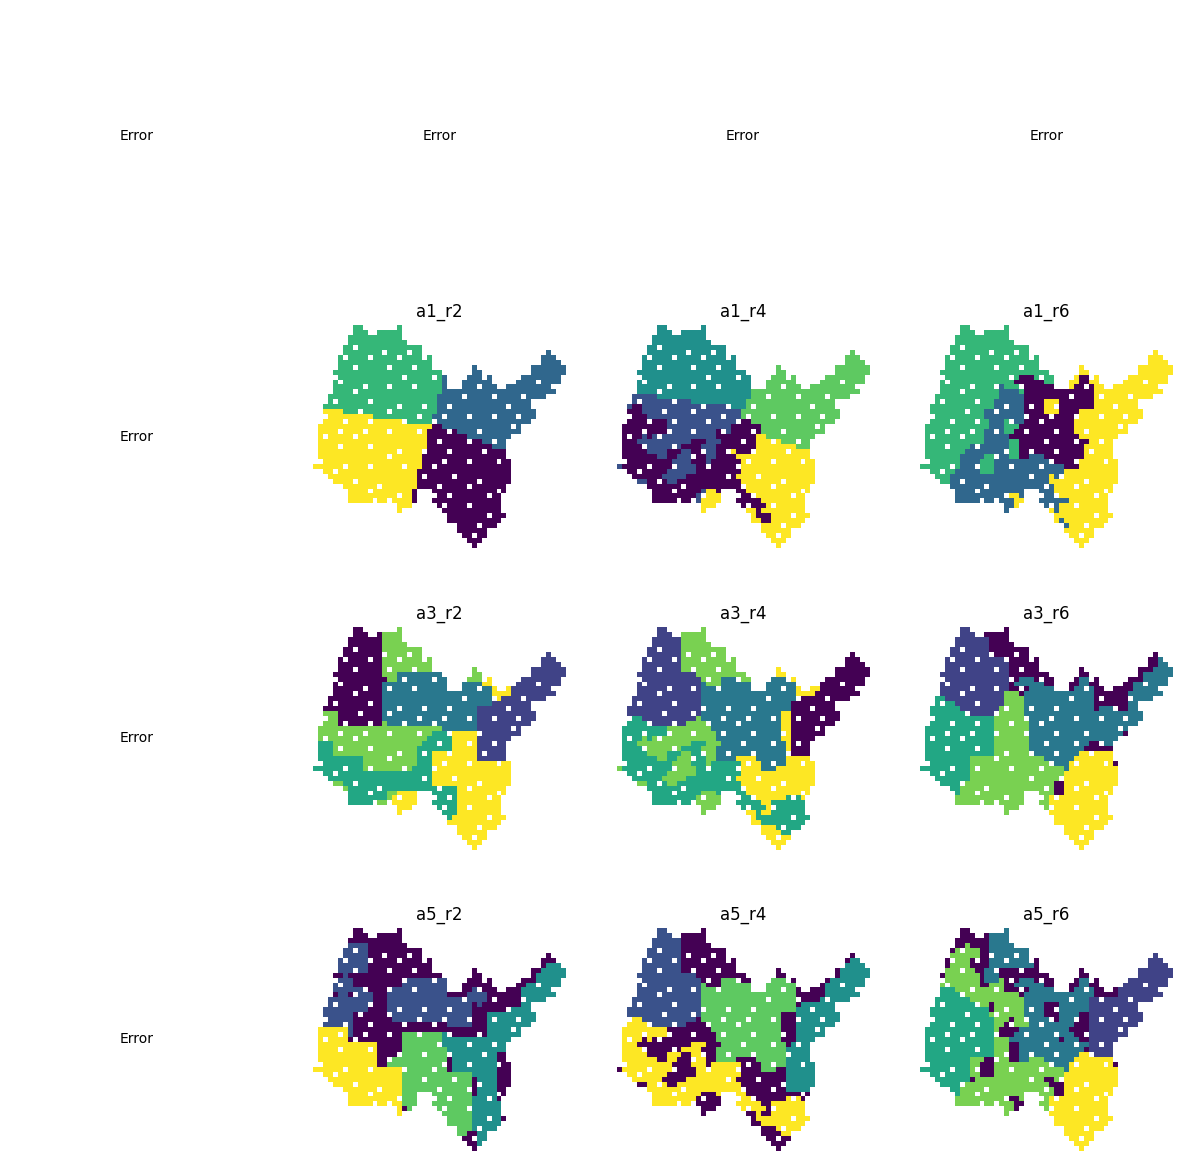

In [193]:
plot_grid_search_attempt_reduce_2D(nb_attempts, n_reduce_classes, 3, 'risk-size-watershed')

/media/caron/X9 Pro/travaille/Thèse/segmentation/risk-size-watershed/s1_aNone_r4/raster departement-01-ainrasterScale1_risk-size-watershed_node.pkl
####################### Check cluster size of risk-size-watershed_s1_aNone_r4
Error loading /media/caron/X9 Pro/travaille/Thèse/segmentation/risk-size-watershed/s1_aNone_r4/raster: '>' not supported between instances of 'NoneType' and 'int'
/media/caron/X9 Pro/travaille/Thèse/segmentation/risk-size-watershed/s1_a1_r4/raster departement-01-ainrasterScale1_risk-size-watershed_node.pkl
####################### Check cluster size of risk-size-watershed_s1_a1_r4
2.0 area 15 is less than 22.5
3.0 area 17 is less than 22.5
4.0 area 4 is less than 22.5
5.0 area 10 is less than 22.5
7.0 area 17 is less than 22.5
8.0 area 4 is less than 22.5
9.0 area 7 is less than 22.5
10.0 area 15 is less than 22.5
11.0 area 12 is less than 22.5
12.0 area 22 is less than 22.5
13.0 area 14 is less than 22.5
14.0 area 4 is less than 22.5
15.0 area 20 is less than 22.5

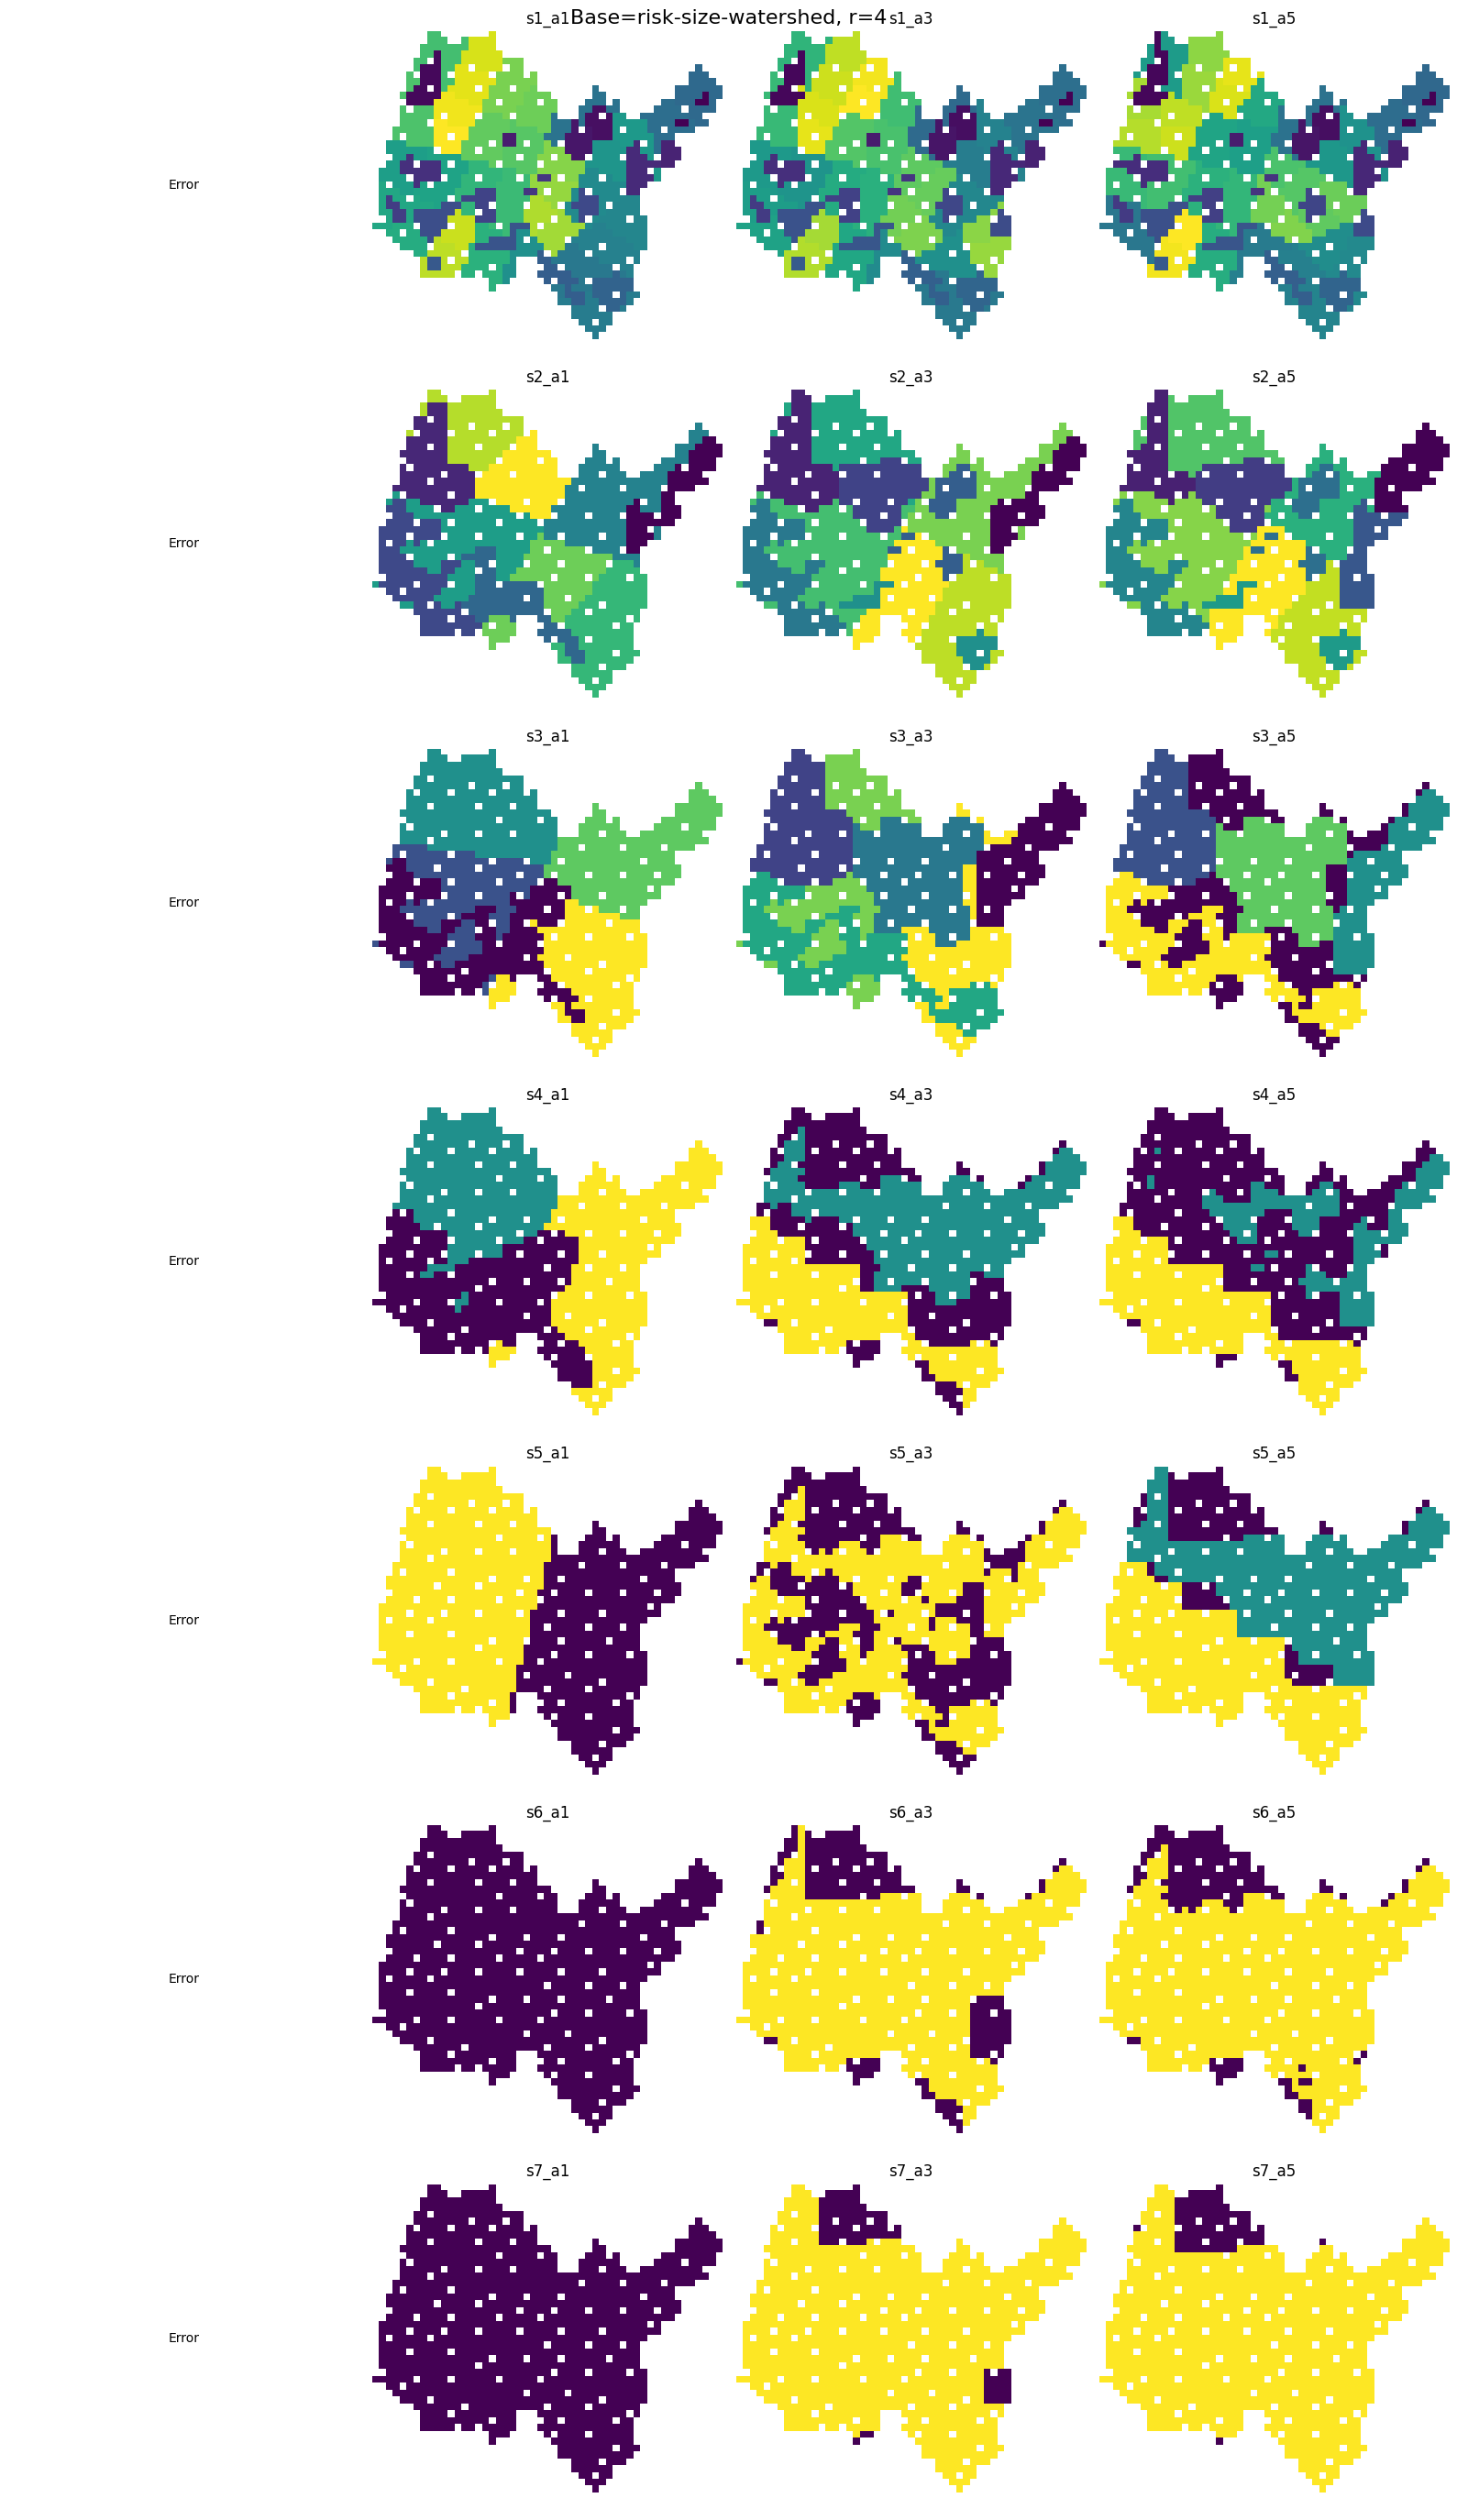

In [194]:
plot_grid_scale_attempt_2D(scales, nb_attempts, 4, 'risk-size-watershed')

/media/caron/X9 Pro/travaille/Thèse/segmentation/risk-size-watershed/s1_a5_rNone/raster departement-01-ainrasterScale1_risk-size-watershed_node.pkl
####################### Check cluster size of risk-size-watershed_s1_a5_rNone
Error loading /media/caron/X9 Pro/travaille/Thèse/segmentation/risk-size-watershed/s1_a5_rNone/raster: '>' not supported between instances of 'NoneType' and 'int'
/media/caron/X9 Pro/travaille/Thèse/segmentation/risk-size-watershed/s1_a5_r2/raster departement-01-ainrasterScale1_risk-size-watershed_node.pkl
####################### Check cluster size of risk-size-watershed_s1_a5_r2
1.0 area 19 is less than 22.5
2.0 area 21 is less than 22.5
3.0 area 12 is less than 22.5
4.0 area 15 is less than 22.5
5.0 area 9 is less than 22.5
6.0 area 15 is less than 22.5
7.0 area 15 is less than 22.5
8.0 area 12 is less than 22.5
9.0 area 10 is less than 22.5
10.0 area 11 is less than 22.5
11.0 area 15 is less than 22.5
14.0 area 54 is higher than 27.5
16.0 area 19 is less than 2

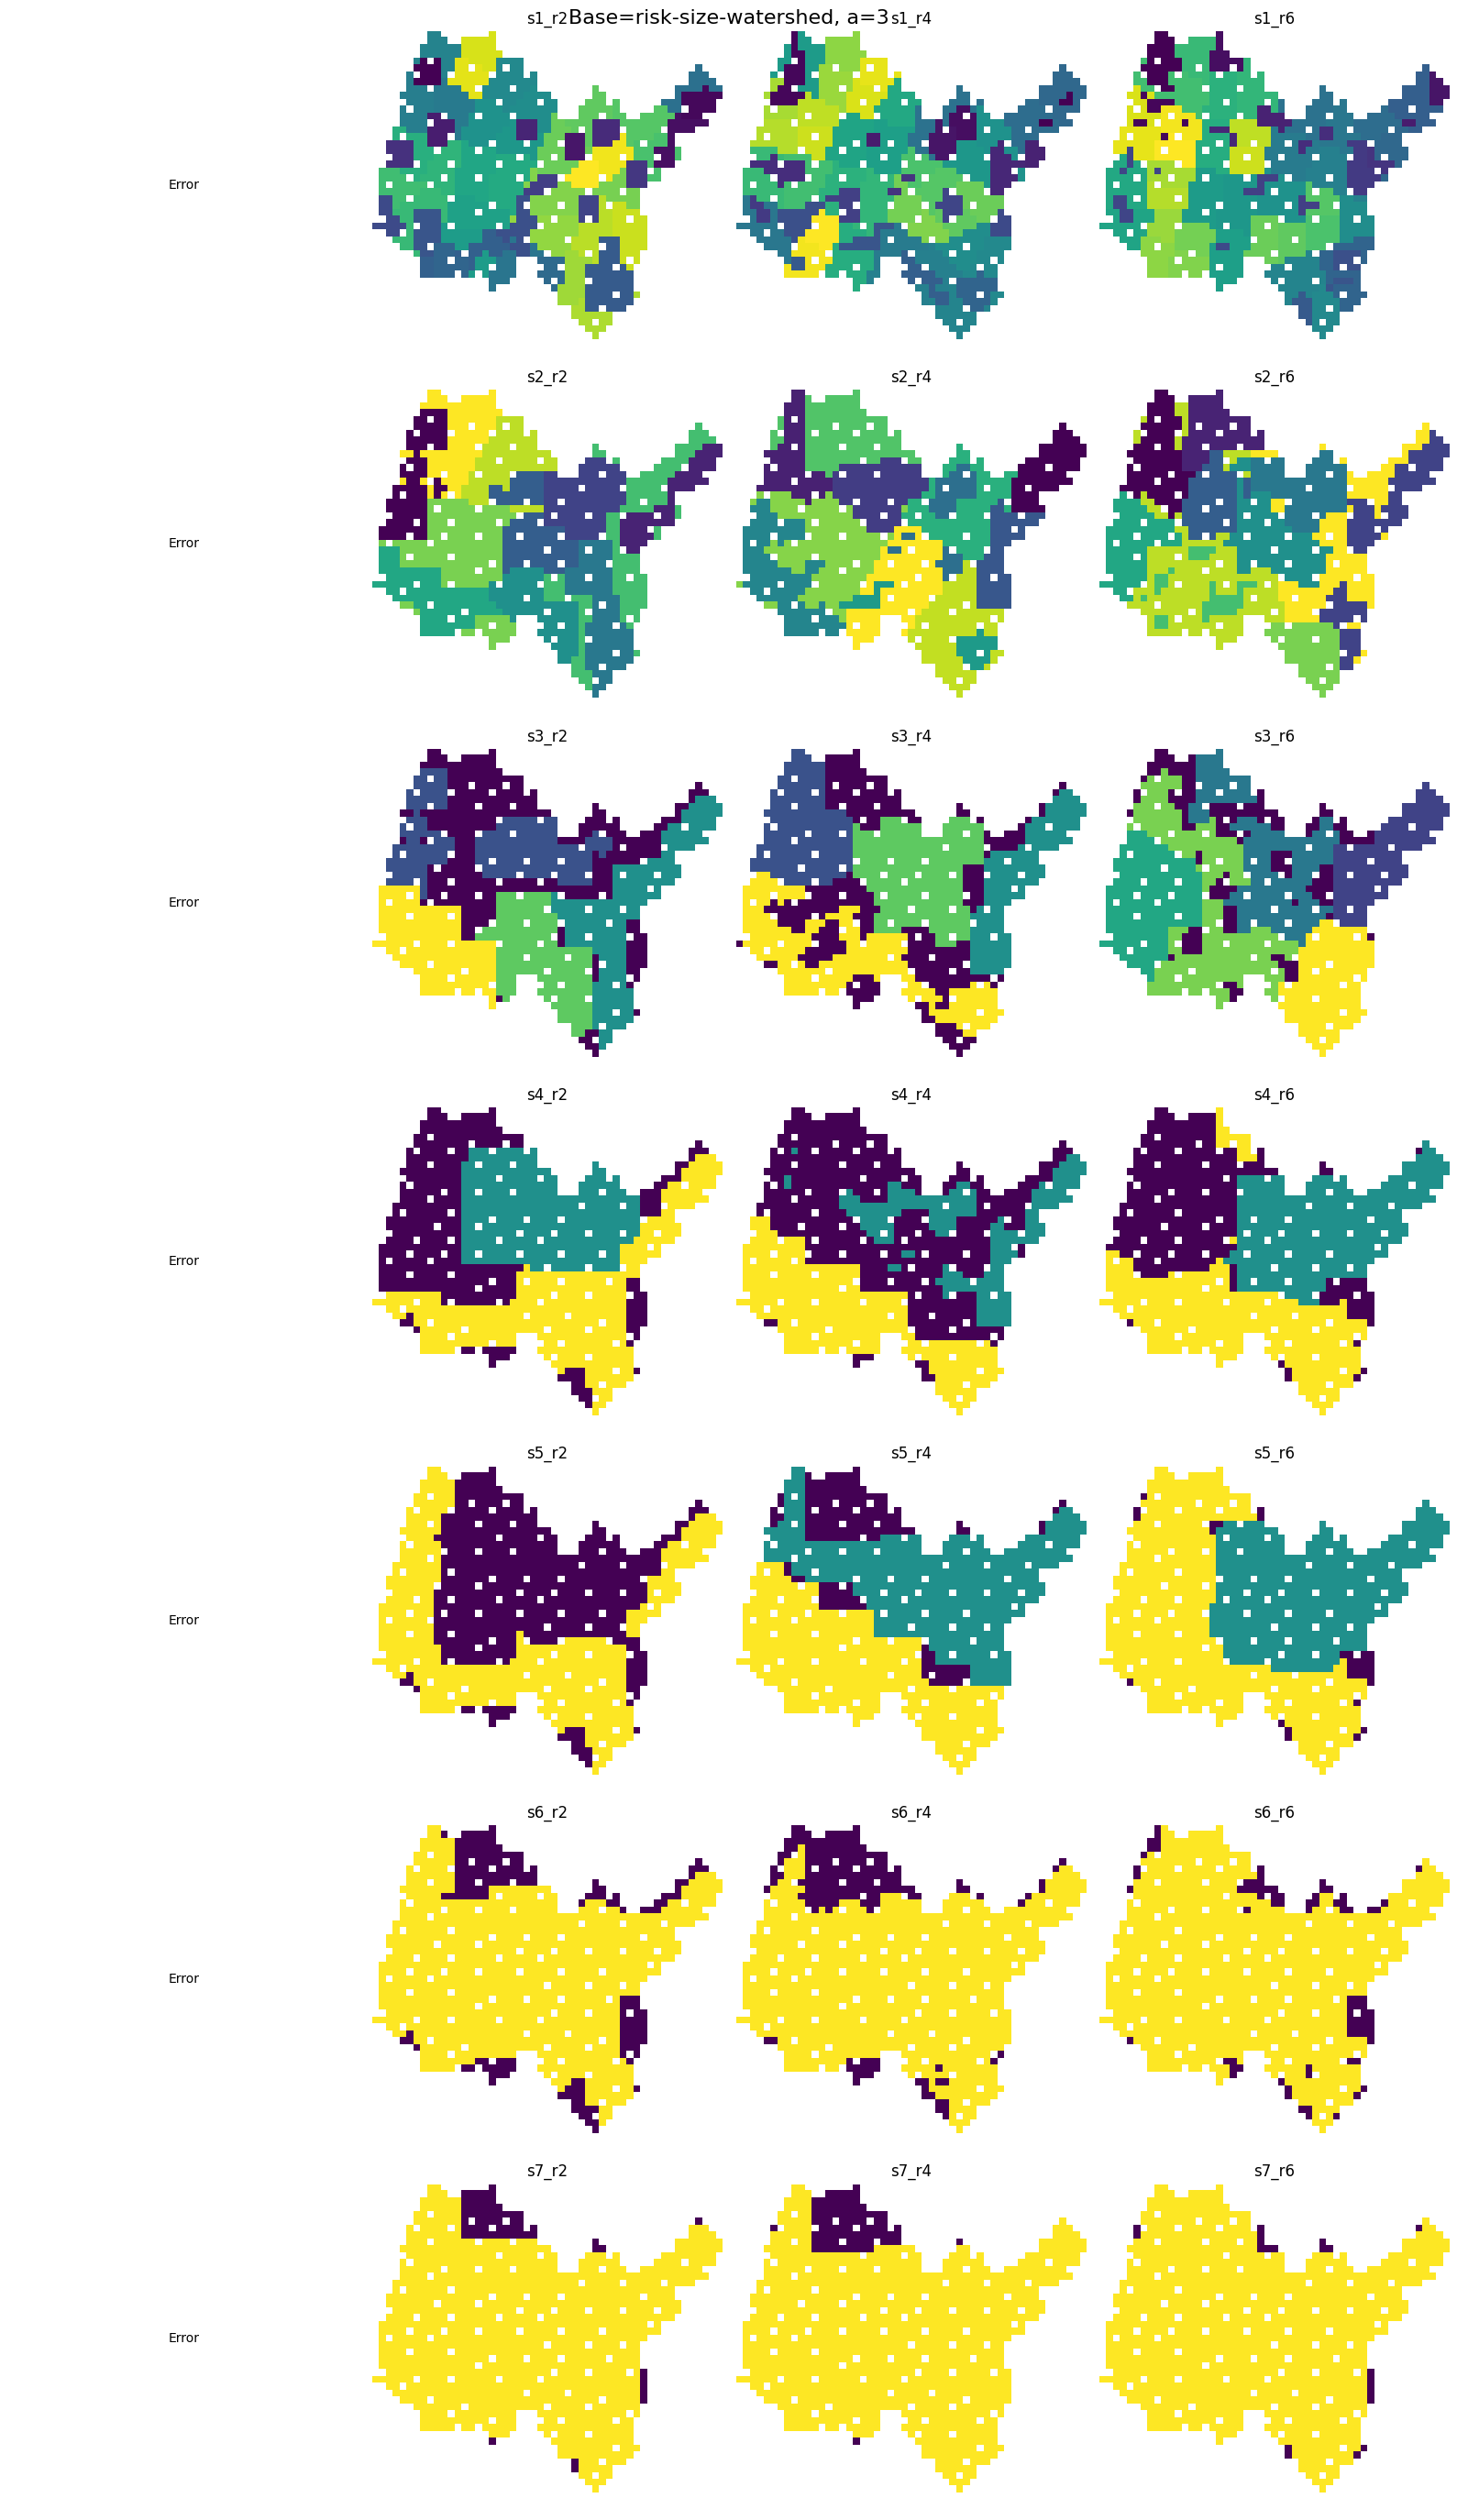

In [195]:
plot_grid_scale_reduce_2D(scales, n_reduce_classes, 3, 'risk-size-watershed')

# Clustering

/media/caron/X9 Pro/travaille/Thèse/segmentation/risk-size-clustering/s7_aNone_rNone/raster departement-01-ainrasterScale7_risk-size-clustering_node.pkl
####################### Check cluster size of risk-size-clustering_s7_aNone_rNone
Error loading /media/caron/X9 Pro/travaille/Thèse/segmentation/risk-size-clustering/s7_aNone_rNone/raster: '>' not supported between instances of 'NoneType' and 'int'
/media/caron/X9 Pro/travaille/Thèse/segmentation/risk-size-clustering/s7_aNone_r2/raster departement-01-ainrasterScale7_risk-size-clustering_node.pkl
####################### Check cluster size of risk-size-clustering_s7_aNone_r2
Error loading /media/caron/X9 Pro/travaille/Thèse/segmentation/risk-size-clustering/s7_aNone_r2/raster: '>' not supported between instances of 'NoneType' and 'int'
/media/caron/X9 Pro/travaille/Thèse/segmentation/risk-size-clustering/s7_aNone_r4/raster departement-01-ainrasterScale7_risk-size-clustering_node.pkl
####################### Check cluster size of risk-size

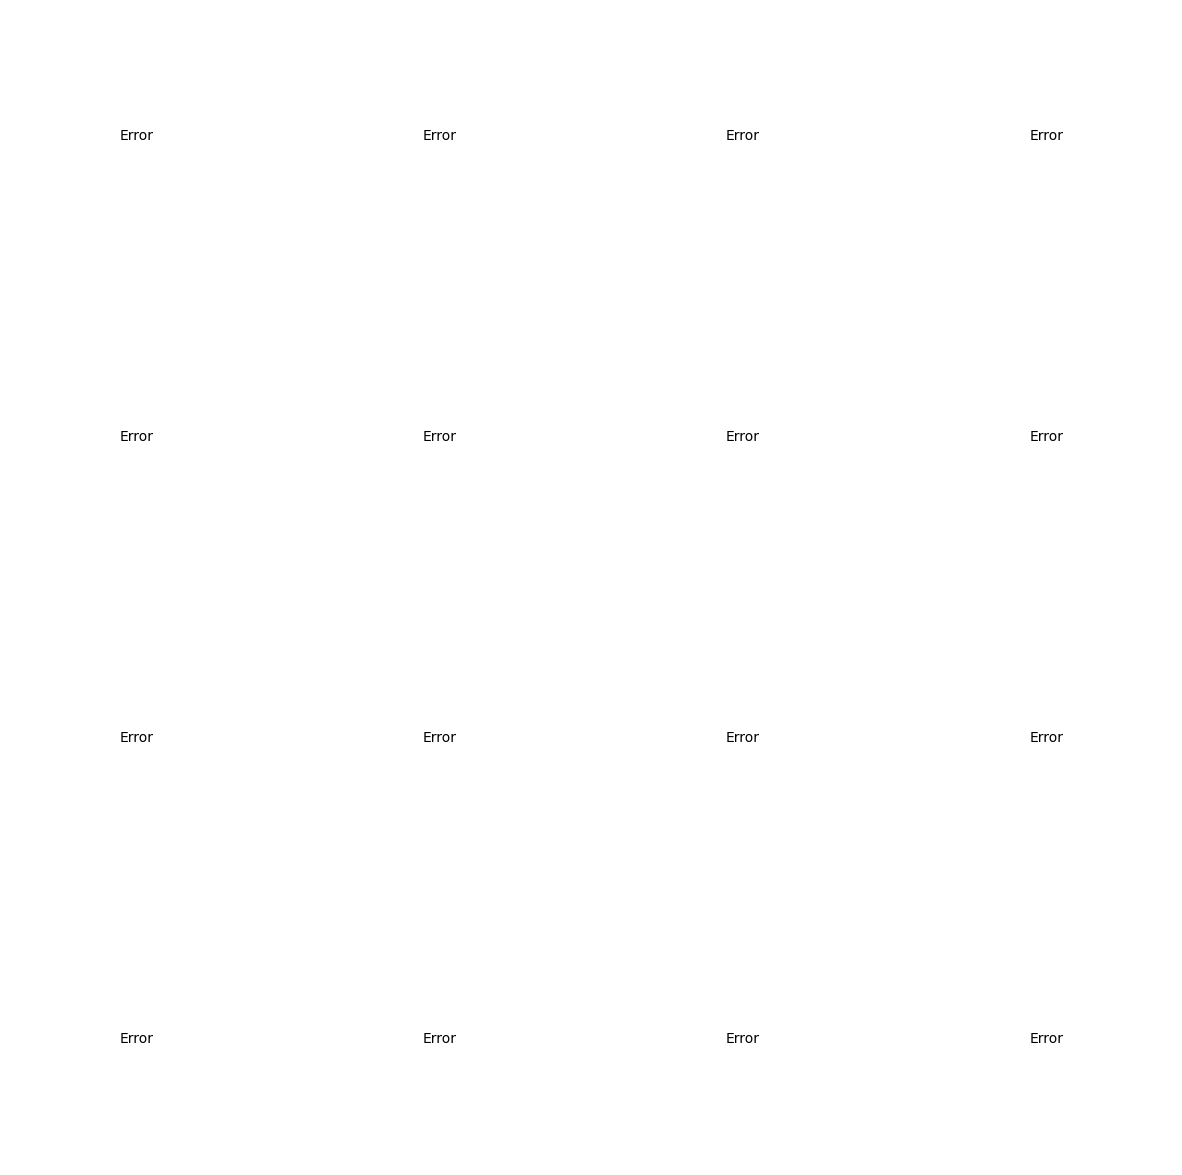

In [196]:
plot_grid_search_attempt_reduce_2D(nb_attempts, n_reduce_classes, 7, 'risk-size-clustering')

# Clustering vs watershed

/media/caron/X9 Pro/travaille/Thèse/segmentation/risk-size-watershed/s1_a3_r4/raster departement-01-ainrasterScale1_risk-size-watershed_node.pkl
####################### Check cluster size of risk-size-watershed_s1_a5_r4
1.0 area 22 is less than 22.5
2.0 area 15 is less than 22.5
3.0 area 17 is less than 22.5
4.0 area 4 is less than 22.5
5.0 area 10 is less than 22.5
7.0 area 17 is less than 22.5
8.0 area 4 is less than 22.5
9.0 area 7 is less than 22.5
10.0 area 15 is less than 22.5
11.0 area 12 is less than 22.5
12.0 area 9 is less than 22.5
13.0 area 22 is less than 22.5
14.0 area 14 is less than 22.5
15.0 area 4 is less than 22.5
16.0 area 20 is less than 22.5
18.0 area 28 is higher than 27.5
19.0 area 33 is higher than 27.5
20.0 area 32 is higher than 27.5
21.0 area 36 is higher than 27.5
22.0 area 28 is higher than 27.5
24.0 area 35 is higher than 27.5
25.0 area 15 is less than 22.5
26.0 area 33 is higher than 27.5
27.0 area 31 is higher than 27.5
29.0 area 19 is less than 22.5
30

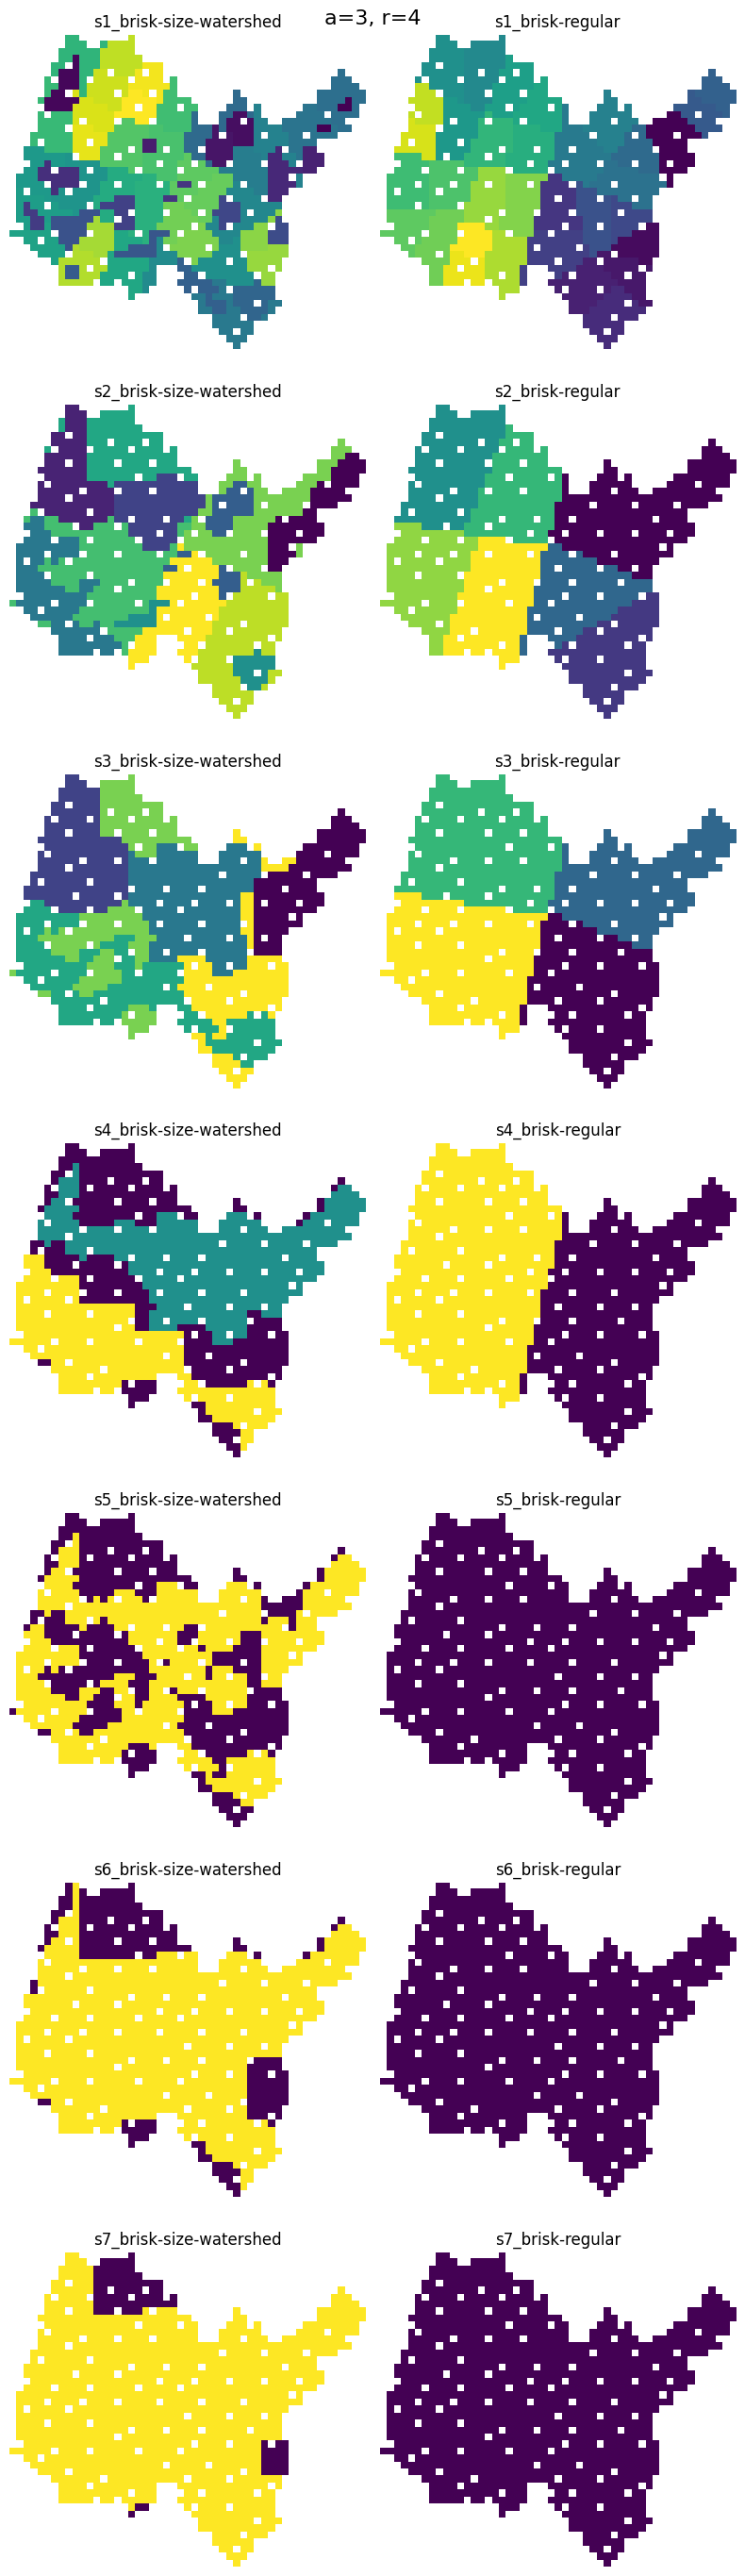

In [197]:
plot_grid_scale_base_2D(scales, bases, 3, 4)

/media/caron/X9 Pro/travaille/Thèse/segmentation/risk-size-watershed/s7_aNone_r4/raster departement-01-ainrasterScale7_risk-size-watershed_node.pkl
####################### Check cluster size of risk-size-watershed_s7_aNone_r4
Error loading /media/caron/X9 Pro/travaille/Thèse/segmentation/risk-size-watershed/s7_aNone_r4/raster: '>' not supported between instances of 'NoneType' and 'int'
/media/caron/X9 Pro/travaille/Thèse/segmentation/risk-regular/s7_aNone_rNone/raster departement-01-ainrasterScale7_risk-regular_node.pkl
####################### Check cluster size of risk-regular_s7_aNone_r4
/media/caron/X9 Pro/travaille/Thèse/segmentation/risk-size-watershed/s7_a1_r4/raster departement-01-ainrasterScale7_risk-size-watershed_node.pkl
####################### Check cluster size of risk-size-watershed_s7_a1_r4
/media/caron/X9 Pro/travaille/Thèse/segmentation/risk-regular/s7_aNone_rNone/raster departement-01-ainrasterScale7_risk-regular_node.pkl
####################### Check cluster size of 

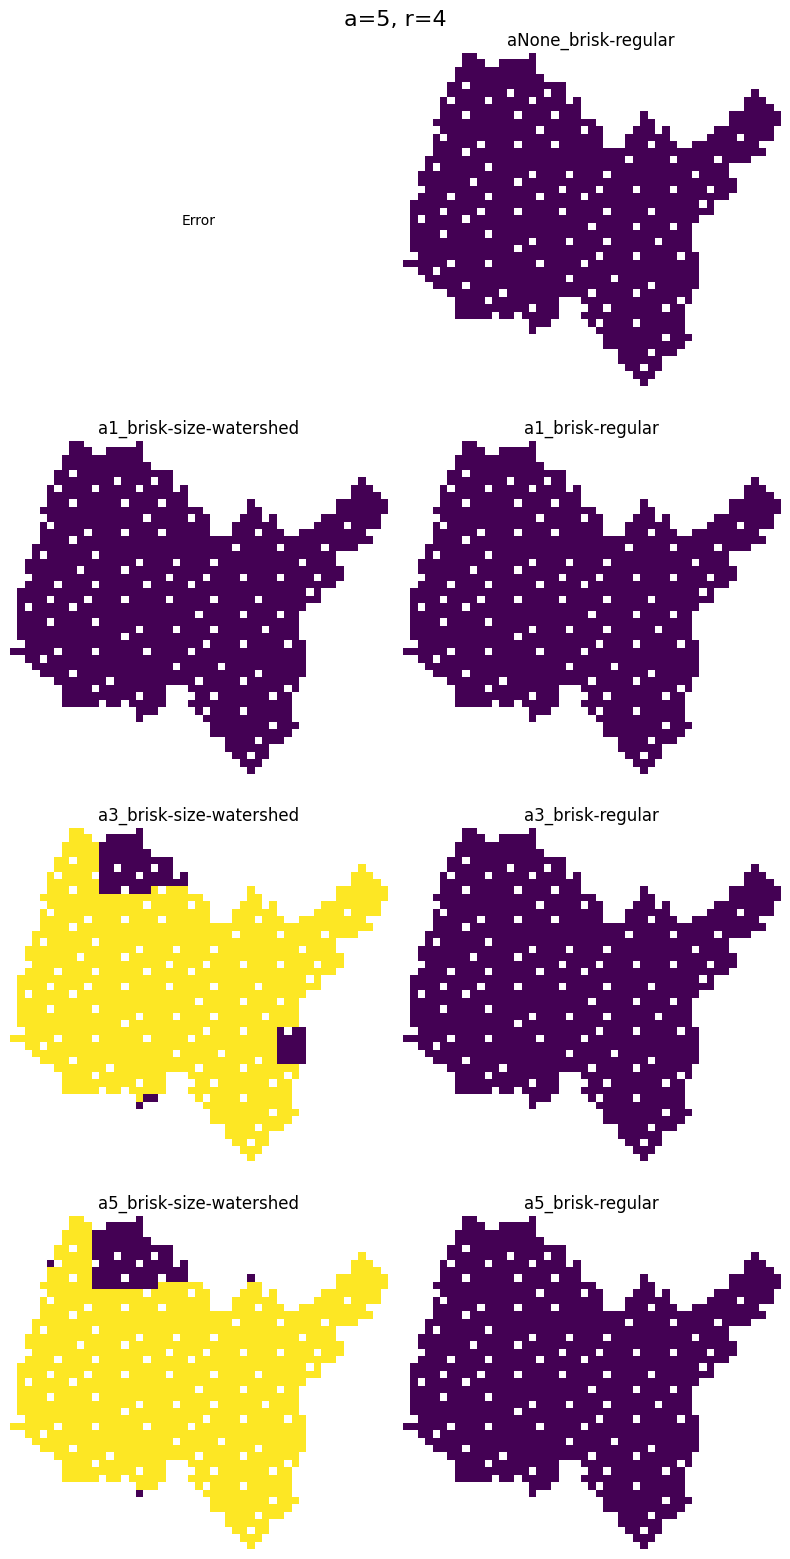

In [198]:
plot_grid_attempt_base_2D(nb_attempts, bases, 7, 4)

In [199]:
from array_fet import *

def get_features_name_list(scale, features, methods):
    features_name = []
    if scale == 0:
        methods = ['mean']
    for var in features:
        if var == 'Calendar':
            features_name += calendar_variables
        elif var == 'air':
            features_name += air_variables
        elif var in landcover_variables:
            features_name += [f'{var}_{met}' for met in methods]
        elif var == 'sentinel':
            features_name += [f'{v}_{met}' for v in sentinel_variables for met in methods]
        elif var == "foret":
            features_name += [f'{foretint2str[v]}_{met}' for v in foret_variables for met in methods]
        elif var == 'dynamicWorld':
            features_name += [f'{v}_{met}' for v in dynamic_world_variables for met in methods]
        elif var == 'cosia':
            features_name += [f'{v}_{met}' for v in cosia_variables for met in methods]
        elif var == 'highway':
            features_name += [f'{osmnxint2str[v]}_{met}' for v in osmnx_variables for met in methods]
        elif var == 'Geo':
            features_name += geo_variables
        elif var == 'vigicrues':
            features_name += [f'{v}_{met}' for v in vigicrues_variables for met in methods]
        elif var == 'nappes':
            features_name += [f'{v}_{met}' for v in nappes_variables for met in methods]
        elif var == 'Historical':
            features_name += [f'{v}' for v in historical_variables]
        elif var == 'AutoRegressionReg':
            features_name += [f'AutoRegressionReg-{v}' for v in auto_regression_variable_reg]
        elif var == 'AutoRegressionBin':
            features_name +=  [f'AutoRegressionBin-{v}' for v in auto_regression_variable_bin]
        elif var == 'elevation':
            features_name += [f'{v}_{met}' for v in elevation_variables for met in methods]
        elif var == 'population':
            features_name += [f'{v}_{met}' for v in population_variabes for met in methods]
        elif var == 'region_class':
            features_name += [var]
        elif var == 'Past_risk' or var == 'Past_bunredarea':
            features_name += [var]
        elif var in varying_time_variables_name:
            features_name += [var]
        elif var == 'temporal_prediction' or var == 'spatial_prediction':
            features_name += [var]
        elif var.find('frequencyratio') != -1:
            features_name += [var]
        elif var in cluster_encoder:
            features_name += [var]
        else:
            features_name += [f'{var}_{met}' for met in methods]

    return features_name, len(features_name)

import matplotlib.pyplot as plt
import seaborn as sns

def plot_correlation_matrix(corr_matrix, feature_names=None, id_labels=None, method='pearson'):
    """
    Affiche la matrice de corrélation (n_feat x n_ids) avec une heatmap.

    Args:
        corr_matrix (np.ndarray): Matrice (n_feat, n_ids)
        feature_names (list[str], optional): Noms des features (longueur = n_feat)
        id_labels (list[int], optional): IDs correspondants aux colonnes (longueur = n_ids)
        method (str): Méthode de corrélation pour le titre ('pearson' ou 'spearman')
    """
    plt.figure(figsize=(10, 6))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
                xticklabels=id_labels if id_labels is not None else "auto",
                yticklabels=feature_names if feature_names is not None else [f"feat_{i}" for i in range(corr_matrix.shape[0])])
    plt.xlabel("ID")
    plt.ylabel("Feature")
    plt.title(f"Matrice de corrélation ({method})")
    plt.tight_layout()
    plt.show()

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.patches import Patch

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

def plot_correlation_with_maps_and_summary(corr_matrix, IDs, feature_names=None, id_labels=None, method='pearson'):
    """
    Affiche :
    - la matrice de corrélation (n_feat x n_ids),
    - la carte des IDs (avec légende),
    - un barplot des moyennes par feature,
    - un boxplot unique regroupant toutes les corrélations.

    Args:
        corr_matrix (np.ndarray): Matrice (n_feat, n_ids) des corrélations.
        IDs (np.ndarray): Image 2D (H, W), avec IDs > 0.
        feature_names (list[str], optional): Noms des features.
        id_labels (list[int], optional): Liste des IDs.
        method (str): 'pearson' ou 'spearman'.
    """
    n_feat, n_ids = corr_matrix.shape
    feature_names = feature_names if feature_names is not None else [f"feat_{i}" for i in range(n_feat)]
    id_labels = id_labels if id_labels is not None else [f"ID {i}" for i in range(n_ids)]

    fig, axs = plt.subplots(2, 2, figsize=(18, 10))

    # 1. Heatmap des corrélations
    sns.heatmap(
        corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
        xticklabels=id_labels, yticklabels=feature_names, ax=axs[0, 0]
    )
    axs[0, 0].set_title(f"Matrice de corrélation ({method})")
    axs[0, 0].set_xlabel("ID")
    axs[0, 0].set_ylabel("Feature")

    # 2. Carte des IDs
    cmap = plt.cm.get_cmap('tab20', int(np.nanmax(IDs)) + 1)
    im_id = axs[0, 1].imshow(IDs, cmap=cmap, vmin=0, vmax=int(np.nanmax(IDs)))
    axs[0, 1].set_title("Carte des IDs")
    axs[0, 1].axis('off')
    unique_ids = np.unique(IDs)
    unique_ids = unique_ids[unique_ids > 0]
    handles = [Patch(color=cmap(uid), label=f"ID {uid}") for uid in unique_ids]
    axs[0, 1].legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left', title="IDs")

    # 3. Barplot : moyenne des corrélations par feature
    # Filtrer les corrélations nulles ou NaN avant la moyenne
    filtered_corr_matrix = np.where(corr_matrix == 0, np.nan, corr_matrix)
    mean_corr = np.nanmean(np.abs(filtered_corr_matrix), axis=1)

    # Barplot avec moyennes filtrées
    axs[1, 0].bar(feature_names, mean_corr, color='steelblue')
    axs[1, 0].set_title("Corrélation moyenne par feature (hors zéros)")
    axs[1, 0].set_ylabel("Corrélation moyenne")
    axs[1, 0].set_xticks(range(n_feat))
    axs[1, 0].set_xticklabels(feature_names, rotation=90)
    
    sns.boxplot(data=[np.abs(mean_corr)], ax=axs[1, 1])
    axs[1, 1].set_title("Distribution globale des corrélations (hors zéros)")
    axs[1, 1].set_ylabel("Corrélation")
    axs[1, 1].set_xticklabels(["Toutes features"])

    plt.tight_layout()
    plt.show()


In [200]:
foretint2str = {
    '0': 'PasDeforet',
    '1': 'Châtaignier',
    '2': 'Chênes décidus',
    '3': 'Chênes sempervirents',
    '4': 'Conifères',
    '5': 'Douglas',
    '6': 'Feuillus',
    '7': 'Hêtre',
    '8': 'Mélèze',
    '9': 'Mixtes',
    '10': 'NC',
    '11': 'NR',
    '12': 'Pin à crochets, pin cembro',
    '13': 'Pin autre',
    '14': 'Pin d\'Alep',
    '15': 'Pin laricio, pin noir',
    '16': 'Pin maritime',
    '17': 'Pin sylvestre',
    '18': 'Pins mélangés',
    '19': 'Peuplier',
    '20': 'Robinier',
    '21': 'Sapin, épicéa'
}

osmnxint2str = {
'0' : 'PasDeRoute',
'1':'motorway',
 '2': 'primary',
 '3': 'secondary',
 '4': 'tertiary', 
 '5': 'path'}

In [201]:
from tools import load_features
from arborescence import root_target

root_features = Path(f'/media/caron/X9 Pro/travaille/Thèse/csv/{dept}/raster/2x2')

features_name = ['foret', 'elevation', 'population', 'cosia', 'highway']

all_features_name = get_features_name_list('departement', features_name, [''])[0]

features = load_features(features_name, '2022-06-01', '2022-07-01', root_features)
features = np.moveaxis(features, 0, 2)
target = read_object(f'{dept}binScale0.pkl', root_target)
target = np.nansum(target, axis=2)

In [202]:
features.shape

(45, 51, 39)

In [203]:
import numpy as np
from scipy.stats import pearsonr, spearmanr

def compute_pixelwise_correlation_matrix(target, features, IDs, all_features_name, method='pearson'):
    """
    Calcule la corrélation entre chaque feature (par pixel) et la target pour chaque ID spatial (valeurs positives uniquement).

    Args:
        target (np.ndarray): Image 2D (H, W)
        features (np.ndarray): Image 3D (H, W, n_feat)
        IDs (np.ndarray): Image 2D (H, W) avec des IDs (valeurs entières, 0 = à ignorer)
        method (str): 'pearson' ou 'spearman'

    Returns:
        np.ndarray: Matrice (n_feat, n_ids) des corrélations
    """
    if target.shape != IDs.shape or target.shape != features.shape[:2]:
        raise ValueError("target, IDs, et features doivent avoir des dimensions spatiales compatibles")

    H, W, n_feat = features.shape
    unique_ids = np.unique(IDs)
    unique_ids = unique_ids[unique_ids > 0]  # ignorer les IDs non positifs
    n_ids = len(unique_ids)

    corr_func = pearsonr if method == 'pearson' else spearmanr
    corr_matrix = np.full((n_feat, n_ids), np.nan)  # initialiser avec NaN

    for j, uid in enumerate(unique_ids):
        mask = (IDs == uid) & ~(np.isnan(IDs))

        if np.sum(mask) < 2:
            continue  # corrélation impossible avec < 2 points
        
        y = target[mask]
        for i in range(n_feat):
            x = features[:, :, i][mask]from itertools import product

            y_c = y[~np.isnan(x) & ~np.isnan(y)]
            x = x[~np.isnan(x) & ~np.isnan(y)]
            if np.all(np.isnan(x)) or np.all(np.isnan(y)):
                continue
            corr, _ = corr_func(x, y_c)
            if not np.isnan(corr):
                corr_matrix[i, j] = corr
            else:
                corr_matrix[i, j] = 0

    plot_correlation_with_maps_and_summary(corr_matrix, IDs, all_features_name, id_labels=unique_ids, method=method)
    return corr_matrix


/tmp/ipykernel_58701/499575758.py:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = corr_func(x, y_c)


2025-05-19 08:20:06,265 [INFO ]  Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-05-19 08:20:06,270 [INFO ]  Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


/tmp/ipykernel_58701/2257090864.py:121: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', int(np.nanmax(IDs)) + 1)
/tmp/ipykernel_58701/2257090864.py:133: RuntimeWarning: Mean of empty slice
  mean_corr = np.nanmean(np.abs(filtered_corr_matrix), axis=1)


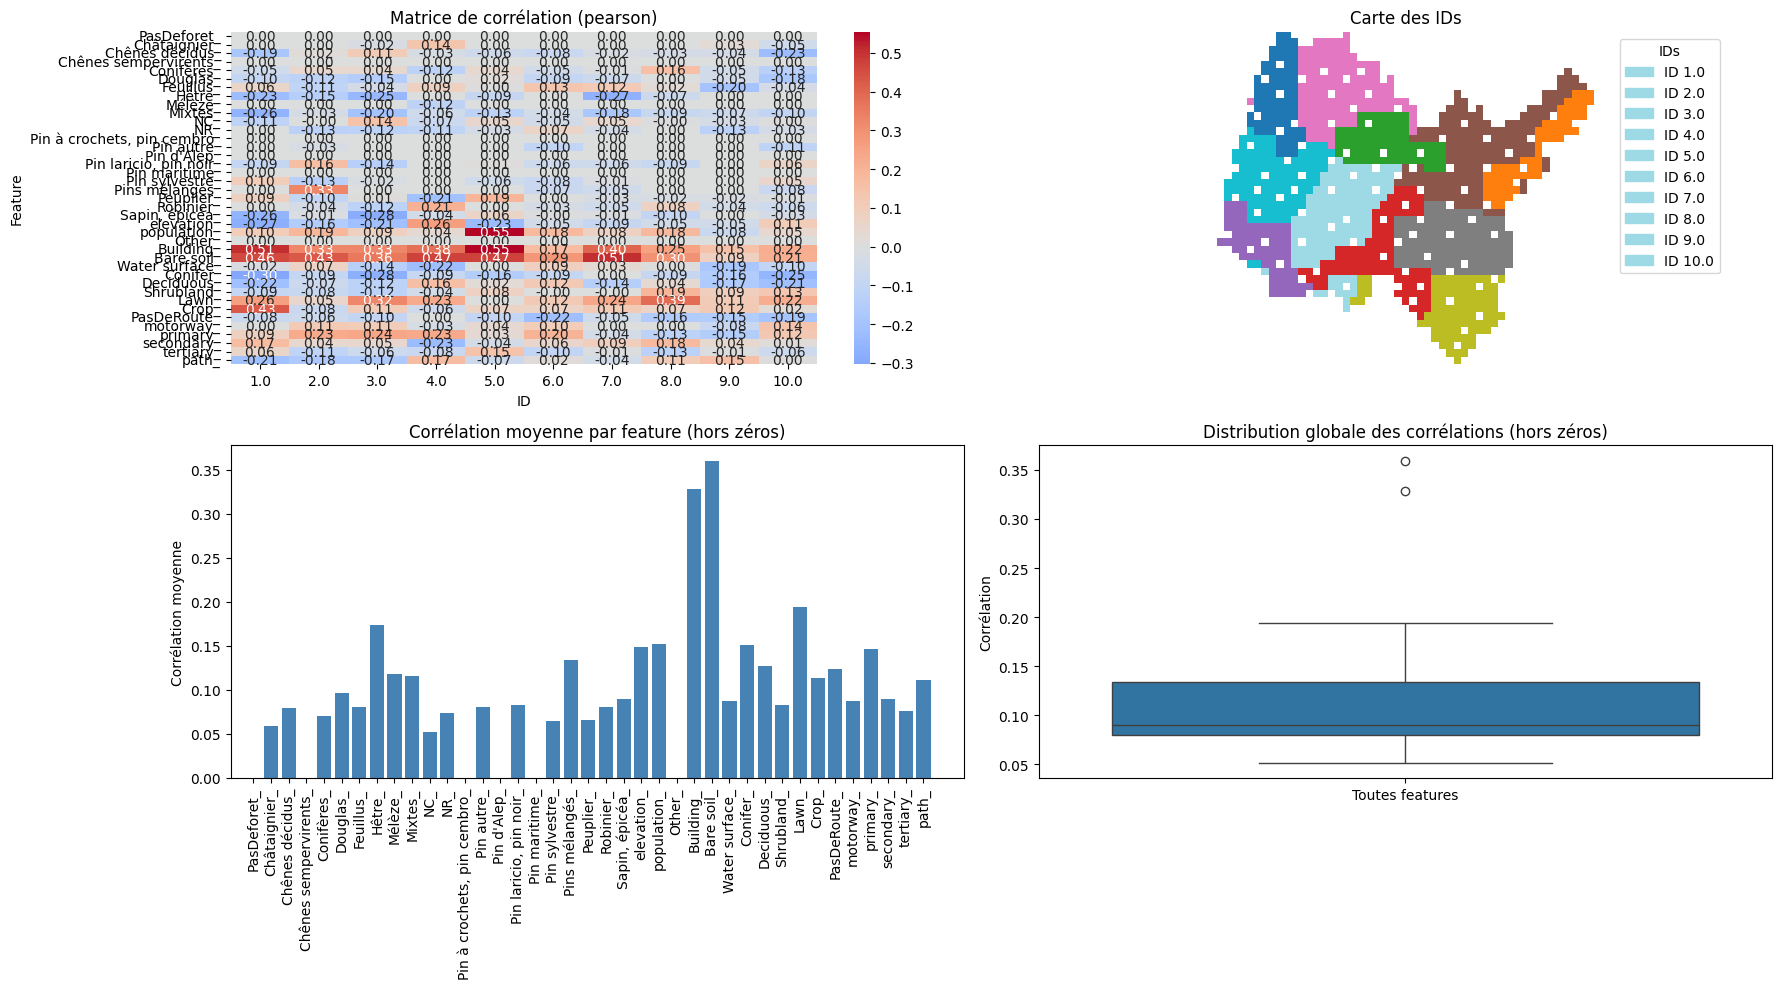

In [209]:
base = 'risk-size-watershed'
scale = '2'
nb_attempt = 3
n_reduce_class = 2

path_file = path / f'{base}/s{scale}_a{nb_attempt}_r{n_reduce_class}/raster/'
file = read_object(f'{dept}rasterScale{scale}_{base}_node.pkl', path_file)

corr = compute_pixelwise_correlation_matrix(target, features, file, all_features_name, method='pearson')

In [205]:
file

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])

/tmp/ipykernel_58701/499575758.py:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = corr_func(x, y_c)
/tmp/ipykernel_58701/2257090864.py:121: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', int(np.nanmax(IDs)) + 1)
/tmp/ipykernel_58701/2257090864.py:133: RuntimeWarning: Mean of empty slice
  mean_corr = np.nanmean(np.abs(filtered_corr_matrix), axis=1)


2025-05-19 08:20:18,457 [INFO ]  Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-05-19 08:20:18,466 [INFO ]  Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


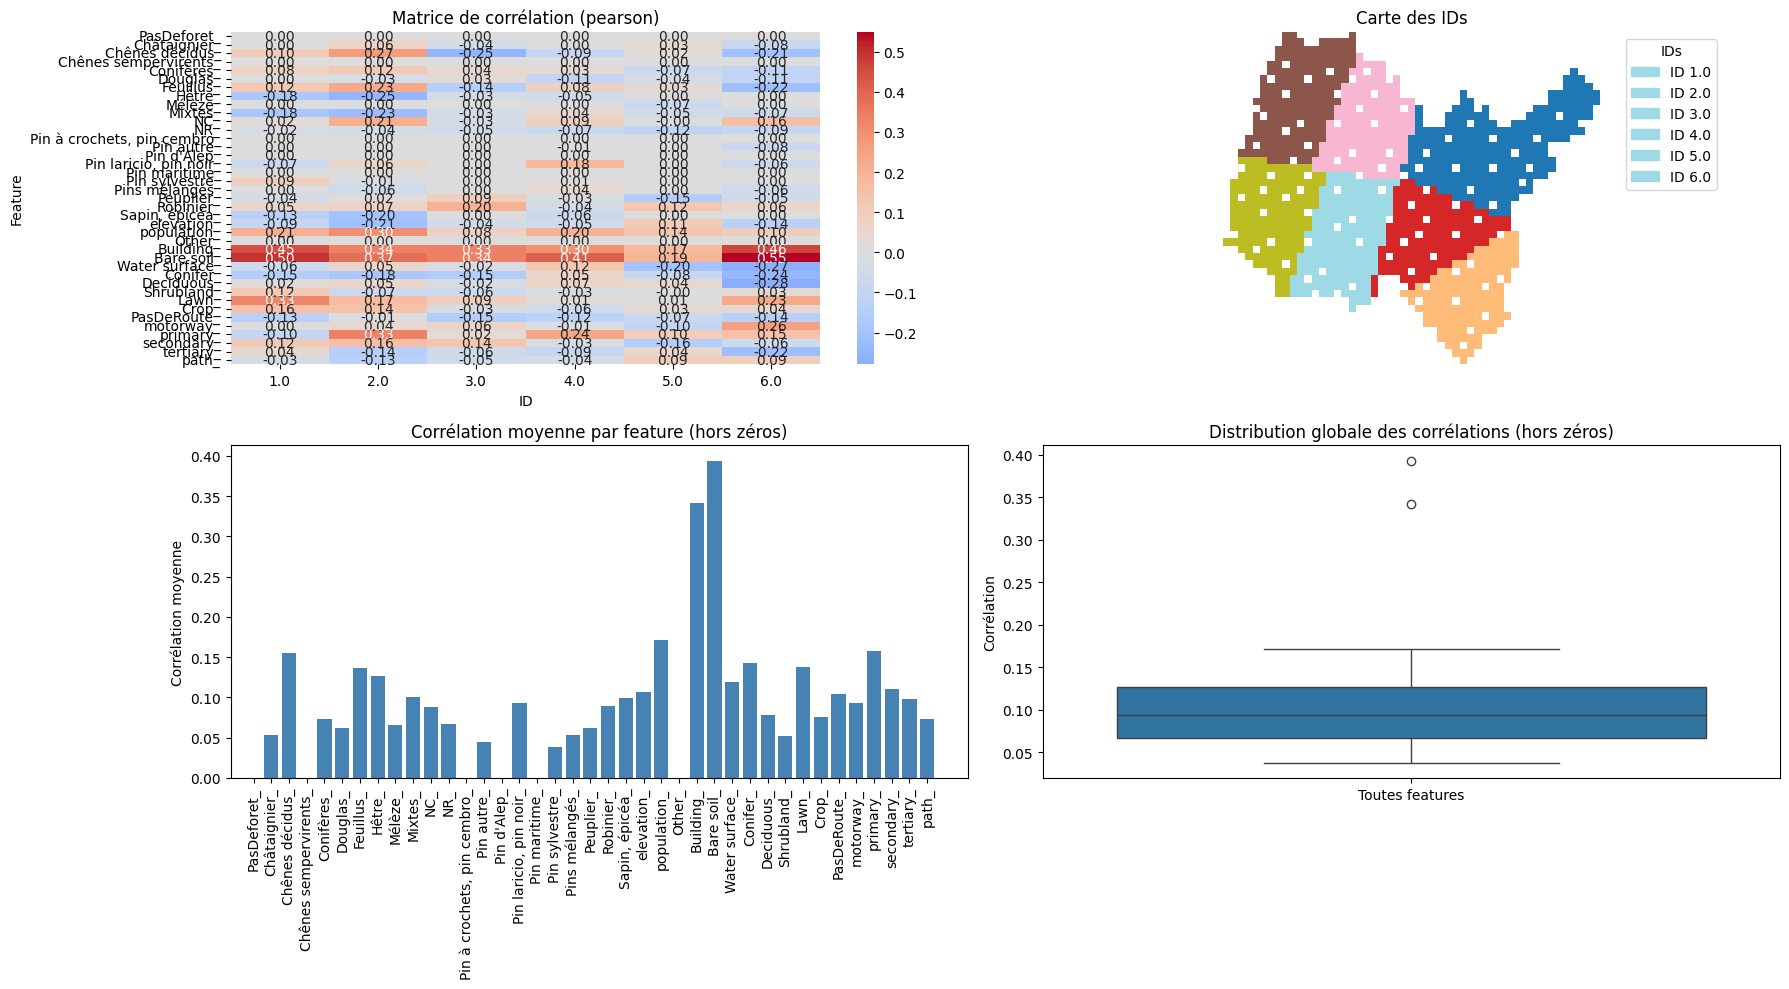

In [210]:
base = 'risk-regular'
scale = 2
nb_attempt = None
n_reduce_class = None

#path_file = path / f'{base}/s{scale}_a{nb_attempt}_r{n_reduce_class}/{scale}_{base}_{base}/{dept}'
path_file = path / f'{base}/s{scale}_a{nb_attempt}_r{n_reduce_class}' / 'raster'
file = read_object(f'{dept}rasterScale{scale}_{base}_node.pkl', path_file)

corr = compute_pixelwise_correlation_matrix(target, features, file, all_features_name, method='pearson')

/tmp/ipykernel_58701/499575758.py:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = corr_func(x, y_c)
/tmp/ipykernel_58701/2257090864.py:121: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', int(np.nanmax(IDs)) + 1)
/tmp/ipykernel_58701/2257090864.py:133: RuntimeWarning: Mean of empty slice
  mean_corr = np.nanmean(np.abs(filtered_corr_matrix), axis=1)


2025-05-19 08:18:52,089 [INFO ]  Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-05-19 08:18:52,097 [INFO ]  Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


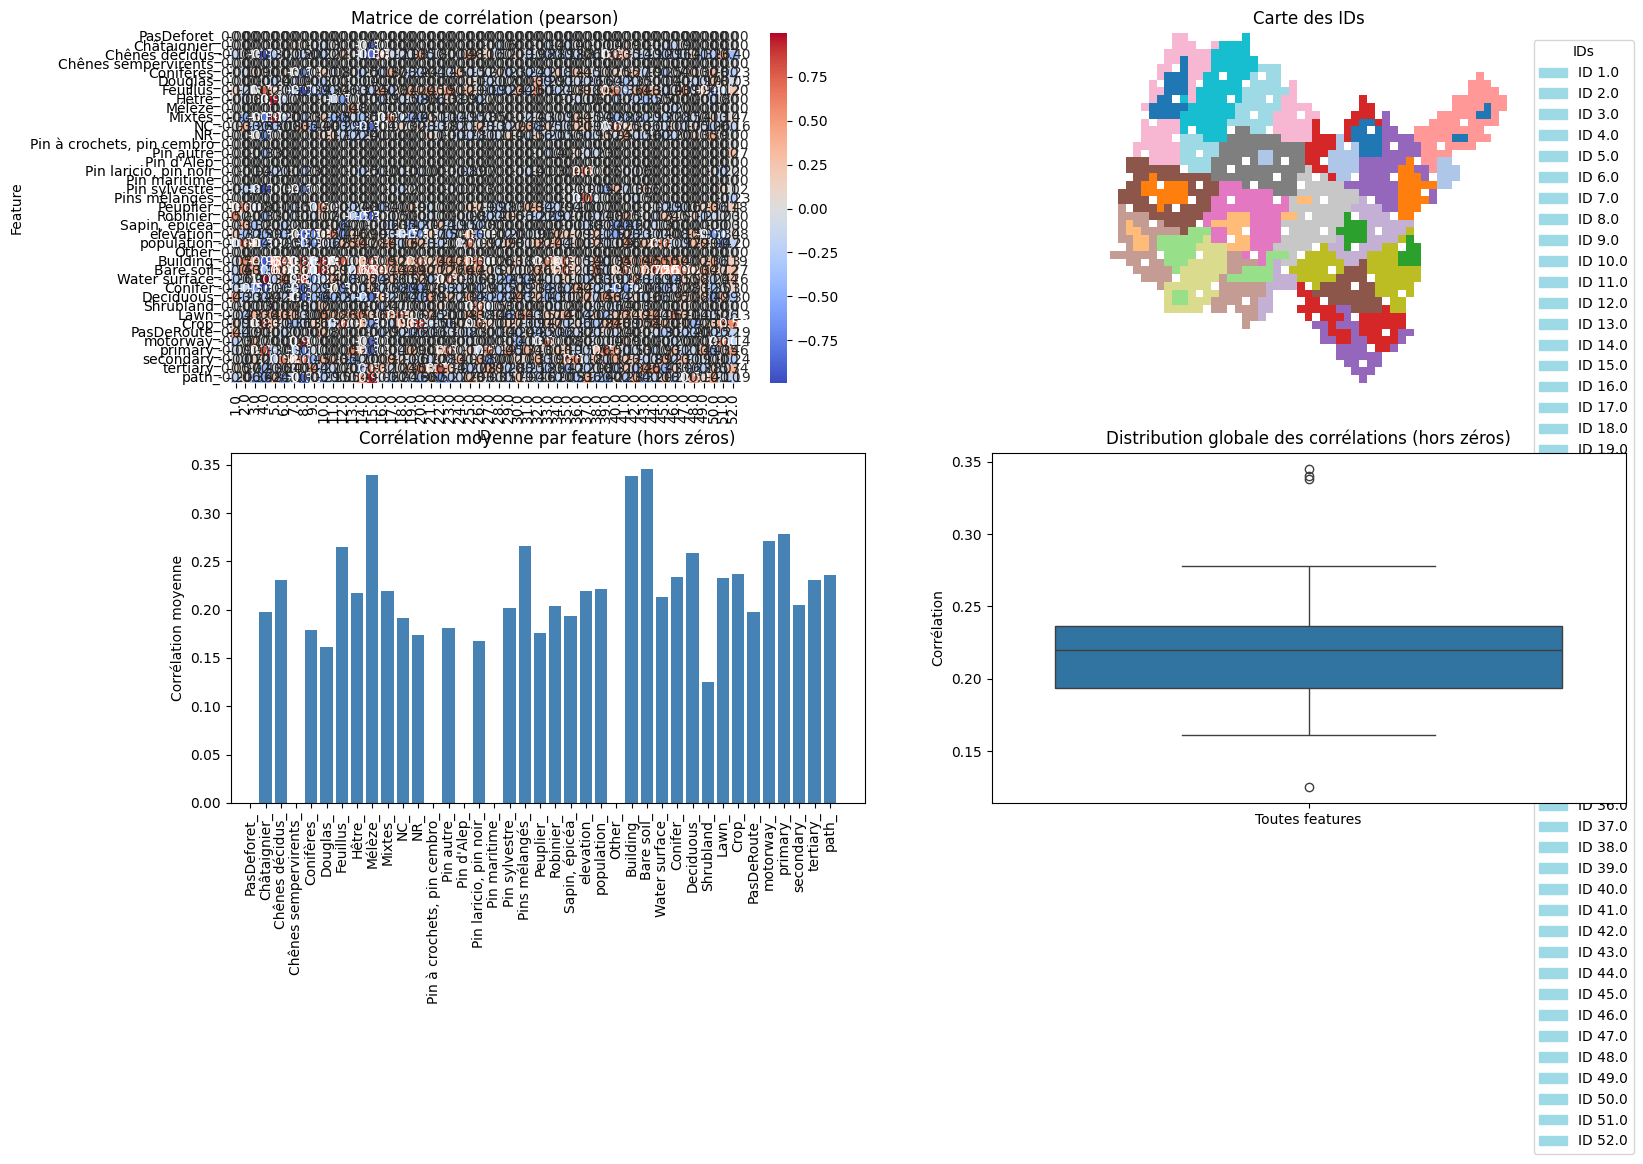

In [207]:
base = 'risk-size-watershed'
scale = '1'
nb_attempt = 3
n_reduce_class = 4

path_file = path / f'{base}/s{scale}_a{nb_attempt}_r{n_reduce_class}/raster/'
file = read_object(f'{dept}rasterScale{scale}_{base}_node.pkl', path_file)

corr = compute_pixelwise_correlation_matrix(target, features, file, all_features_name, method='pearson')

/tmp/ipykernel_58701/499575758.py:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = corr_func(x, y_c)
/tmp/ipykernel_58701/2257090864.py:121: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', int(np.nanmax(IDs)) + 1)
/tmp/ipykernel_58701/2257090864.py:133: RuntimeWarning: Mean of empty slice
  mean_corr = np.nanmean(np.abs(filtered_corr_matrix), axis=1)


2025-05-19 08:18:56,421 [INFO ]  Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-05-19 08:18:56,428 [INFO ]  Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


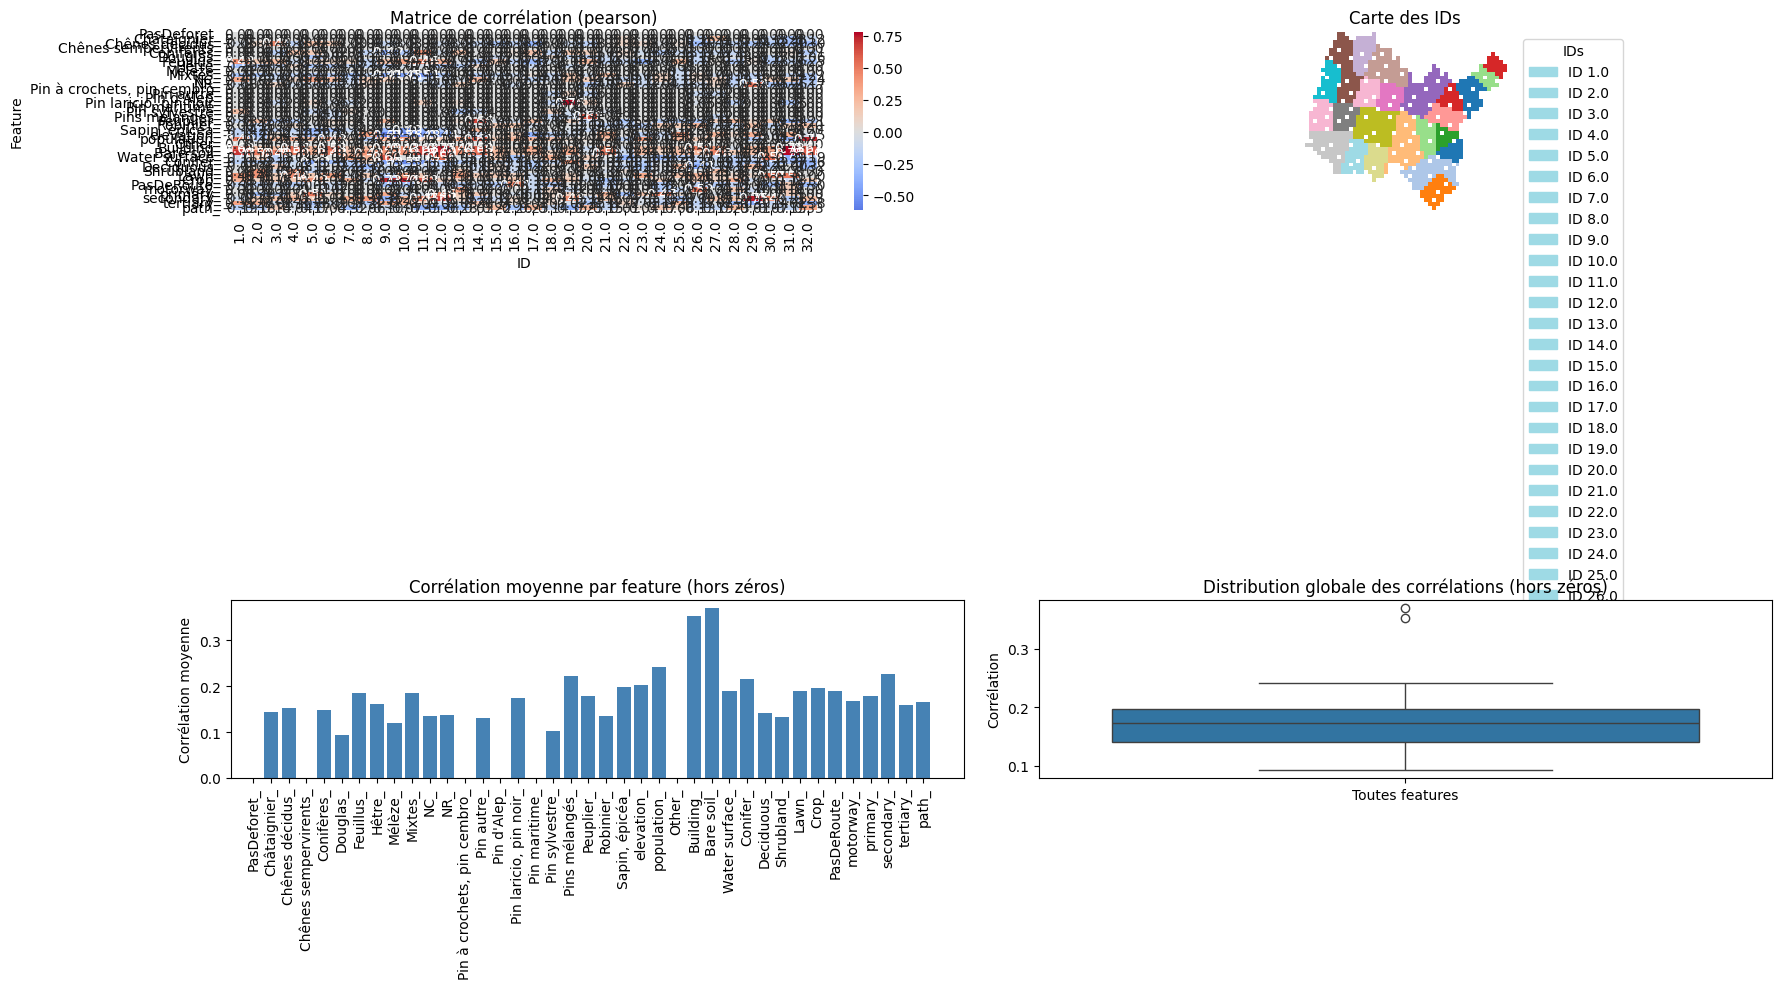

In [208]:
base = 'risk-regular'
scale = 1
nb_attempt = None
n_reduce_class = None

#path_file = path / f'{base}/s{scale}_a{nb_attempt}_r{n_reduce_class}/{scale}_{base}_{base}/{dept}'
path_file = path / f'{base}/s{scale}_a{nb_attempt}_r{n_reduce_class}' / 'raster'
file = read_object(f'{dept}rasterScale{scale}_{base}_node.pkl', path_file)

corr = compute_pixelwise_correlation_matrix(target, features, file, all_features_name, method='pearson')